# Airport Network Analysis — Centrality Analysis

This notebook identifies influential airports using degree, PageRank, and approximate betweenness centrality.

### Objective

The objective of this notebook is to identify the most influential airports in the global airport network using multiple graph-theoretic centrality measures.

Specifically, this notebook investigates:

- Degree centrality to identify highly connected hub airports.
- PageRank to identify airports connected to other important airports.
- Betweenness centrality to identify airports that act as bridges between different regions.
- A comparison of these measures to understand different aspects of airport importance.

In [9]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph

G = build_graph('../Data')

## 1. Degree centrality

Degree centrality measures direct connections. In-degree represents destinations served; out-degree represents destinations reached.

In [10]:
degree = dict(G.degree())
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

degree_results = pd.DataFrame([
    {
        'airport_id': node, 'airport': G.nodes[node]['name'],
        'city': G.nodes[node]['city'], 'country': G.nodes[node]['country'],
        'total_degree': degree[node], 'in_degree': in_degree[node], 'out_degree': out_degree[node]
    }
    for node in G.nodes
]).sort_values('total_degree', ascending=False).head(15)
degree_results.reset_index(drop=True)

,airport_id,airport,city,country,total_degree,in_degree,out_degree
0,340,Frankfurt am Main Airport,Frankfurt,Germany,477,238,239
1,1382,Charles de Gaulle International Airport,Paris,France,470,233,237
2,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,463,231,232
3,1701,Atatürk International Airport,Istanbul,Turkey,451,227,224
4,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,433,216,217
5,3830,Chicago O'Hare International Airport,Chicago,United States,409,203,206
6,3364,Beijing Capital International Airport,Beijing,China,408,204,204
7,346,Munich Airport,Munich,Germany,380,189,191
8,4029,Domodedovo International Airport,Moscow,Russia,375,188,187
9,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,372,185,187


### Interpretation

The degree ranking identifies airports with the highest number of direct flight connections in the global airport network.

Frankfurt, Charles de Gaulle, Amsterdam Schiphol, Istanbul Atatürk, and Hartsfield–Jackson Atlanta appear among the highest-ranked airports because they serve as major international hubs with extensive direct connectivity.

A high total degree indicates strong local connectivity and suggests that these airports play an essential role in maintaining efficient passenger and cargo transportation across the worldwide aviation network.

## 2. PageRank

PageRank rewards airports that are linked from other important airports, rather than simply counting direct connections.

In [11]:
pagerank = nx.pagerank(G, alpha=0.85)
pagerank_results = pd.DataFrame([
    {'airport_id': node, 'airport': G.nodes[node]['name'], 'city': G.nodes[node]['city'],
     'country': G.nodes[node]['country'], 'pagerank': score}
    for node, score in pagerank.items()
]).sort_values('pagerank', ascending=False).head(15)
pagerank_results.reset_index(drop=True)

,airport_id,airport,city,country,pagerank
0,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,0.004922
1,3830,Chicago O'Hare International Airport,Chicago,United States,0.004512
2,1701,Atatürk International Airport,Istanbul,Turkey,0.004482
3,3751,Denver International Airport,Denver,United States,0.004430
4,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,0.004409
5,4029,Domodedovo International Airport,Moscow,Russia,0.004213
6,1382,Charles de Gaulle International Airport,Paris,France,0.004137
7,340,Frankfurt am Main Airport,Frankfurt,Germany,0.004018
8,3364,Beijing Capital International Airport,Beijing,China,0.003951
9,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.003809


### Interpretation

Unlike total degree, PageRank measures airport importance by considering not only the number of direct connections but also the importance of the airports to which they are connected.

Airports such as Hartsfield–Jackson Atlanta, Chicago O'Hare, Istanbul Atatürk, and Denver International achieve high PageRank values because they are connected to other highly influential airports within the global aviation network.

This demonstrates that airport importance depends not only on the number of direct routes but also on the quality and strategic significance of those connections.

## 3. Betweenness centrality

Betweenness detects transfer airports that lie on many shortest paths. A 200-node sample provides a practical approximation for this network.

In [12]:
betweenness = nx.betweenness_centrality(G, k=200, seed=42, normalized=True)
betweenness_results = pd.DataFrame([
    {'airport_id': node, 'airport': G.nodes[node]['name'], 'city': G.nodes[node]['city'],
     'country': G.nodes[node]['country'], 'betweenness': score}
    for node, score in betweenness.items()
]).sort_values('betweenness', ascending=False).head(15)
betweenness_results.reset_index(drop=True)

,airport_id,airport,city,country,betweenness
0,1382,Charles de Gaulle International Airport,Paris,France,0.066325
1,3484,Los Angeles International Airport,Los Angeles,United States,0.065991
2,3364,Beijing Capital International Airport,Beijing,China,0.057995
3,2188,Dubai International Airport,Dubai,United Arab Emirates,0.057597
4,340,Frankfurt am Main Airport,Frankfurt,Germany,0.051674
5,3774,Ted Stevens Anchorage International Airport,Anchorage,United States,0.048091
6,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.047055
7,2564,Guarulhos - Governador André Franco Montoro In...,Sao Paulo,Brazil,0.045912
8,507,London Heathrow Airport,London,United Kingdom,0.043726
9,193,Lester B. Pearson International Airport,Toronto,Canada,0.041577


### Interpretation

Betweenness centrality identifies airports that act as critical bridges between different regions of the global airport network.

Unlike degree and PageRank, this measure emphasizes airports that frequently lie on the shortest paths between other airports. Airports such as Charles de Gaulle, Los Angeles International, Beijing Capital, and Dubai International rank highly because they facilitate efficient travel between geographically separated parts of the network.

These airports are particularly important for maintaining global connectivity, since disruptions at these locations can significantly increase network fragmentation and reduce accessibility between regions.

In [13]:
comparison = degree_results[
    ["airport", "total_degree"]
].merge(
    pagerank_results[
        ["airport", "pagerank"]
    ],
    on="airport",
    how="outer"
).merge(
    betweenness_results[
        ["airport", "betweenness"]
    ],
    on="airport",
    how="outer"
)

# Sort while the columns are still numeric
comparison = comparison.sort_values(
    "total_degree",
    ascending=False
).head(15)

# Replace missing values only for display
comparison_display = comparison.fillna("-")

comparison_display

,airport,total_degree,pagerank,betweenness
9,Frankfurt am Main Airport,477.0,0.004018,0.051674
3,Charles de Gaulle International Airport,470.0,0.004137,0.066325
0,Amsterdam Airport Schiphol,463.0,0.003809,0.047055
1,Atatürk International Airport,451.0,0.004482,0.037277
12,Hartsfield Jackson Atlanta International Airport,433.0,0.004922,-
4,Chicago O'Hare International Airport,409.0,0.004512,0.041143
2,Beijing Capital International Airport,408.0,0.003951,0.057995
17,Munich Airport,380.0,-,-
7,Domodedovo International Airport,375.0,0.004213,-
5,Dallas Fort Worth International Airport,372.0,0.004409,-


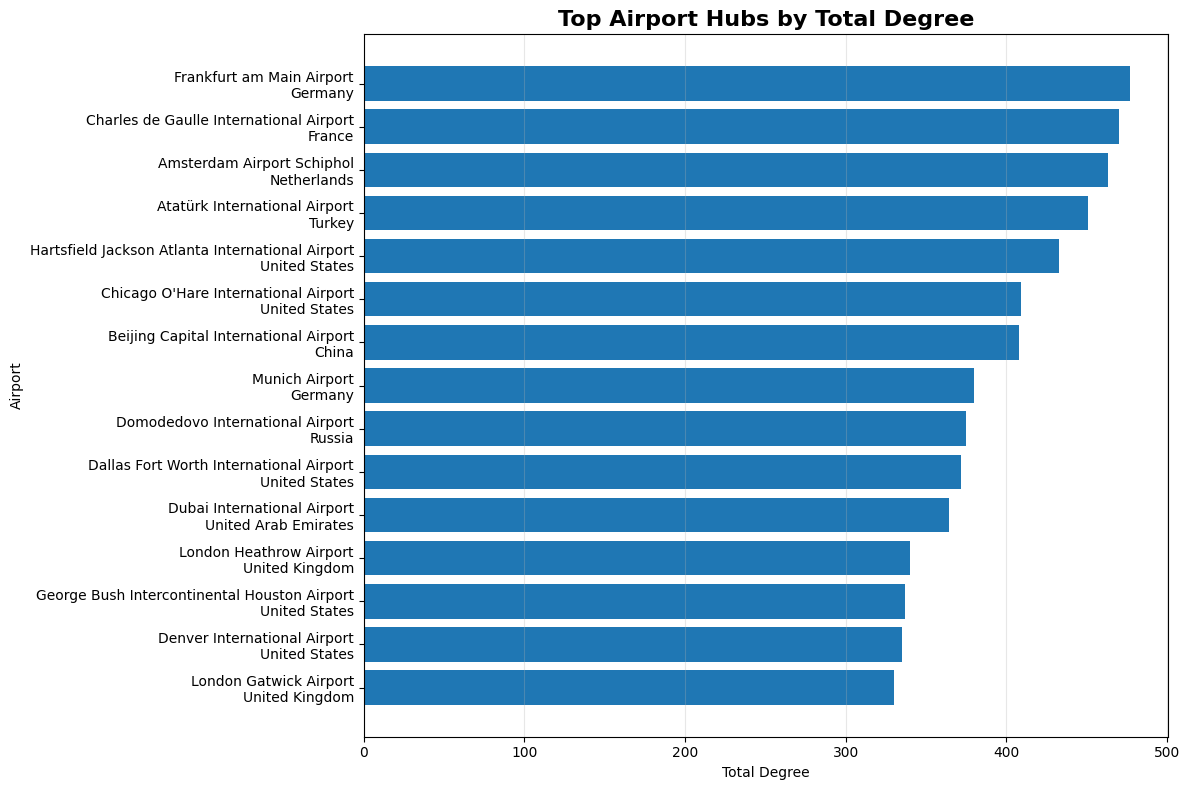

In [14]:
import matplotlib.pyplot as plt

top20 = degree_results.copy()

labels = (
    top20["airport"]
    + "\n"
    + top20["country"]
)

plt.figure(figsize=(12,8))

plt.barh(
    labels[::-1],
    top20["total_degree"][::-1]
)

plt.xlabel("Total Degree")

plt.ylabel("Airport")

plt.title(
    "Top Airport Hubs by Total Degree",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../Reports/figures/top20_hubs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

Airports that rank highly across all three metrics are both well connected and structurally influential. Airports with high betweenness but lower degree are especially important as bridges between regions.